<a href="https://colab.research.google.com/github/valliansayoga/ey-data-challenge-2025/blob/master/EY2025_Create_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://challenge.ey.com/api/v1/storage/admin-files/556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
!wget https://challenge.ey.com/api/v1/storage/admin-files/7286921994693265-678a3479124df4f88e67ef7e-Training_data_uhi_index_UHI2025-v2.csv
!wget https://challenge.ey.com/api/v1/storage/admin-files/8403843075872017-678a346b124df4f88e67ef26-Submission_template_UHI2025-v2.csv

--2025-01-31 07:05:44--  https://challenge.ey.com/api/v1/storage/admin-files/556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
Resolving challenge.ey.com (challenge.ey.com)... 52.236.158.32
Connecting to challenge.ey.com (challenge.ey.com)|52.236.158.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13861358 (13M) [application/octet-stream]
Saving to: ‘556750475068843-678f9918ed9624f63ca75b56-Dataset.zip’

556750475068843-678 100%[===================>]  13.22M  5.68MB/s    in 2.3s    

2025-01-31 07:05:47 (5.68 MB/s) - ‘556750475068843-678f9918ed9624f63ca75b56-Dataset.zip’ saved [13861358/13861358]

--2025-01-31 07:05:47--  https://challenge.ey.com/api/v1/storage/admin-files/7286921994693265-678a3479124df4f88e67ef7e-Training_data_uhi_index_UHI2025-v2.csv
Resolving challenge.ey.com (challenge.ey.com)... 52.236.158.32
Connecting to challenge.ey.com (challenge.ey.com)|52.236.158.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5976

In [ ]:
!unzip 556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
!rm 556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
!mv "7286921994693265-678a3479124df4f88e67ef7e-Training_data_uhi_index_UHI2025-v2.csv" Training_data_uhi_index.csv
!mv "8403843075872017-678a346b124df4f88e67ef26-Submission_template_UHI2025-v2.csv" Submission_template.csv

Archive:  556750475068843-678f9918ed9624f63ca75b56-Dataset.zip
   creating: Dataset/
  inflating: Dataset/2025 EY Open Science AI Data Challenge Participant Guidance.pdf  
  inflating: Dataset/Building_Footprint.kml  
  inflating: Dataset/Landsat_LST.ipynb  
  inflating: Dataset/NY_Mesonet_Weather.xlsx  
  inflating: Dataset/Sentinel2_GeoTIFF.ipynb  
  inflating: Dataset/Submission_template.csv  
  inflating: Dataset/Training_data_uhi_index.csv  
  inflating: Dataset/UHI Experiment Sample Benchmark Notebook V5.ipynb  


In [ ]:
!python -m pip install \
    xarray \
    rioxarray \
    rasterio \
    stackstac \
    pystac_client \
    pystac==1.11.0 \
    planetary_computer \
    odc-stac \
    osmnx \
    pykml \
    geopandas \
    shapely \
    fiona \
    pvlib \
    --quiet
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.2/29.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.8/153.8 kB 11.0 MB/s eta 0:00:00


# Spectral Bands

In [ ]:
# Import common GIS tools
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio
from matplotlib.cm import jet,RdYlGn

# Import Planetary Computer tools
import stackstac
import pystac_client
import planetary_computer
from odc.stac import stac_load, load
import pandas as pd

In [ ]:
time_window = "2021-06-01/2021-08-01"
time_window

'2021-06-01/2021-08-01'

In [ ]:
lower_left = (40.75, -74.01)  # (long, lat)
upper_right = (40.88, -73.86)

In [ ]:
# bounds = (min_lon, min_lat, max_lon, max_lat)
bounds = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])
print(bounds)

(-74.01, 40.75, -73.86, 40.88)


# Landsat Data

In [ ]:
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

search = stac.search(
    bbox=bounds,
    datetime=time_window,
    collections=["landsat-c2-l2"],
    query={"eo:cloud_cover": {"lt": 80},"platform": {"in": ["landsat-8"]}},
)
items = list(search.get_items())
print('Identified items:', len(items))

/usr/local/lib/python3.11/dist-packages/pystac_client/item_search.py:888: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Identified items: 8


In [ ]:
signed_items = [planetary_computer.sign(item).to_dict() for item in items]
resolution = 10  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for crs=4326

In [ ]:
items = search.get_all_items()

/usr/local/lib/python3.11/dist-packages/pystac_client/item_search.py:903: FutureWarning: get_all_items() is deprecated, use item_collection() instead.
  warnings.warn(


In [ ]:
items[0]

<Item id=LC08_L2SP_014032_20210725_02_T1>

In [ ]:
list(items[0].assets.keys())

['qa',
 'ang',
 'red',
 'blue',
 'drad',
 'emis',
 'emsd',
 'trad',
 'urad',
 'atran',
 'cdist',
 'green',
 'nir08',
 'lwir11',
 'swir16',
 'swir22',
 'coastal',
 'mtl.txt',
 'mtl.xml',
 'mtl.json',
 'qa_pixel',
 'qa_radsat',
 'qa_aerosol',
 'tilejson',
 'rendered_preview']

In [ ]:
bands = [
    'red',
    'green',
    'blue',
    'qa',
    'drad',
    'emis',
    'emsd',
    'trad',
    'urad',
    'atran',
    'cdist',
    'nir08',
    'qa_radsat',
    'qa_aerosol',
]
data1 = stac_load(
    items,
    bands=bands,
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)
data2 = stac_load(
    items,
    bands=["lwir11"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)

In [ ]:
display(data1)
display(data2)

<xarray.Dataset> Size: 542MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 8)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 64B 2021-06-07T15:39:15.904901 ... 202...
Data variables: (12/14)
    red          (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    qa           (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    drad         (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    emis         (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    ...           ...
    urad         (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    atran        (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    cdist        (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    nir08        (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    qa_radsat    (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    qa_aerosol   (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

<xarray.Dataset> Size: 39MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 8)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 64B 2021-06-07T15:39:15.904901 ... 202...
Data variables:
    lwir11       (time, latitude, longitude) uint16 39MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

In [ ]:
# Persist the data in memory for faster operations
data1 = data1.persist()
data2 = data2.persist()

In [ ]:
# Scale Factors for the RGB and NIR bands
scale1 = 0.0000275
offset1 = -0.2
data1 = data1.astype(np.float64) * scale1 + offset1

# Scale Factors for the Surface Temperature band
scale2 = 0.00341802
offset2 = 149.0
kelvin_celsius = 273.15 # convert from Kelvin to Celsius
data2 = data2.astype(float) * scale2 + offset2 - kelvin_celsius

In [ ]:
median = data1.median(dim="time")
mean = data1.mean(dim="time")
max = data1.max(dim="time")
min = data1.min(dim="time")
std = data1.std(dim="time")
var = data1.var(dim="time")

In [ ]:
variables = list(data1.variables.keys())
variables

['latitude',
 'longitude',
 'spatial_ref',
 'time',
 'red',
 'green',
 'blue',
 'qa',
 'drad',
 'emis',
 'emsd',
 'trad',
 'urad',
 'atran',
 'cdist',
 'nir08',
 'qa_radsat',
 'qa_aerosol']

In [ ]:
landsat_to_export = list()

stats = ["median", "mean", "max", "min", "std", "var"]
for band in variables[4:]:
    for stat in stats:
        str_eval = f"{band}_{stat} = {stat}.{band}"
        exec(str_eval)

        str_eval = f"{band}_{stat}.name = '{band}_{stat}'"
        exec(str_eval)
        landsat_to_export.append(eval(f"{band}_{stat}"))

for stat in stats:
    exec(f'ndvi_{stat} = ({stat}.nir08 - {stat}.red) / ({stat}.nir08 + {stat}.red)')
    exec(f'evi_{stat} = 2.5 * (({stat}.nir08 - {stat}.red) / ({stat}.nir08 + 6 * {stat}.red - 7.5 * {stat}.blue + 1))')
    exec(f'ndvi_{stat}.name = "ndvi_{stat}"')
    exec(f'evi_{stat}.name = "evi_{stat}"')
    exec(f'lwir_{stat} = data2.lwir11.{stat}(dim="time")')
    exec(f'lwir_{stat}.name = "lwir_{stat}"')
    exec(f'landsat_to_export.extend([ndvi_{stat}, evi_{stat}, lwir_{stat}])')

In [ ]:
sorted(list(map(lambda x: x.name, landsat_to_export)))

['atran_max',
 'atran_mean',
 'atran_median',
 'atran_min',
 'atran_std',
 'atran_var',
 'blue_max',
 'blue_mean',
 'blue_median',
 'blue_min',
 'blue_std',
 'blue_var',
 'cdist_max',
 'cdist_mean',
 'cdist_median',
 'cdist_min',
 'cdist_std',
 'cdist_var',
 'drad_max',
 'drad_mean',
 'drad_median',
 'drad_min',
 'drad_std',
 'drad_var',
 'emis_max',
 'emis_mean',
 'emis_median',
 'emis_min',
 'emis_std',
 'emis_var',
 'emsd_max',
 'emsd_mean',
 'emsd_median',
 'emsd_min',
 'emsd_std',
 'emsd_var',
 'evi_max',
 'evi_mean',
 'evi_median',
 'evi_min',
 'evi_std',
 'evi_var',
 'green_max',
 'green_mean',
 'green_median',
 'green_min',
 'green_std',
 'green_var',
 'lwir_max',
 'lwir_mean',
 'lwir_median',
 'lwir_min',
 'lwir_std',
 'lwir_var',
 'ndvi_max',
 'ndvi_mean',
 'ndvi_median',
 'ndvi_min',
 'ndvi_std',
 'ndvi_var',
 'nir08_max',
 'nir08_mean',
 'nir08_median',
 'nir08_min',
 'nir08_std',
 'nir08_var',
 'qa_aerosol_max',
 'qa_aerosol_mean',
 'qa_aerosol_median',
 'qa_aerosol_min',


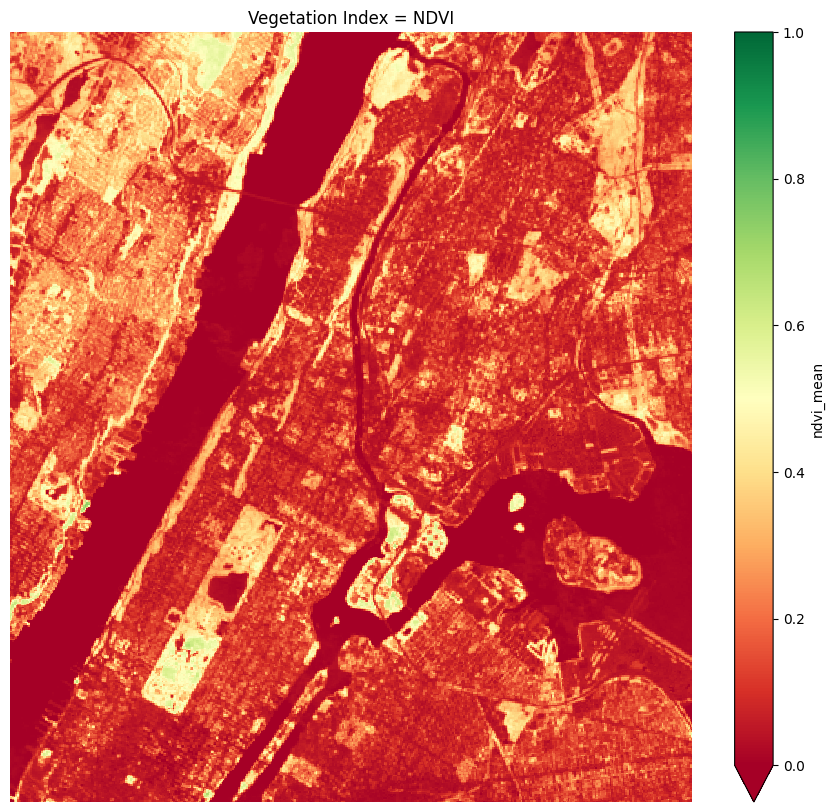

In [ ]:
fig, ax = plt.subplots(figsize=(11,10))
ndvi_mean.plot.imshow(vmin=0.0, vmax=1.0, cmap="RdYlGn")
plt.title("Vegetation Index = NDVI")
plt.axis('off')
plt.show()

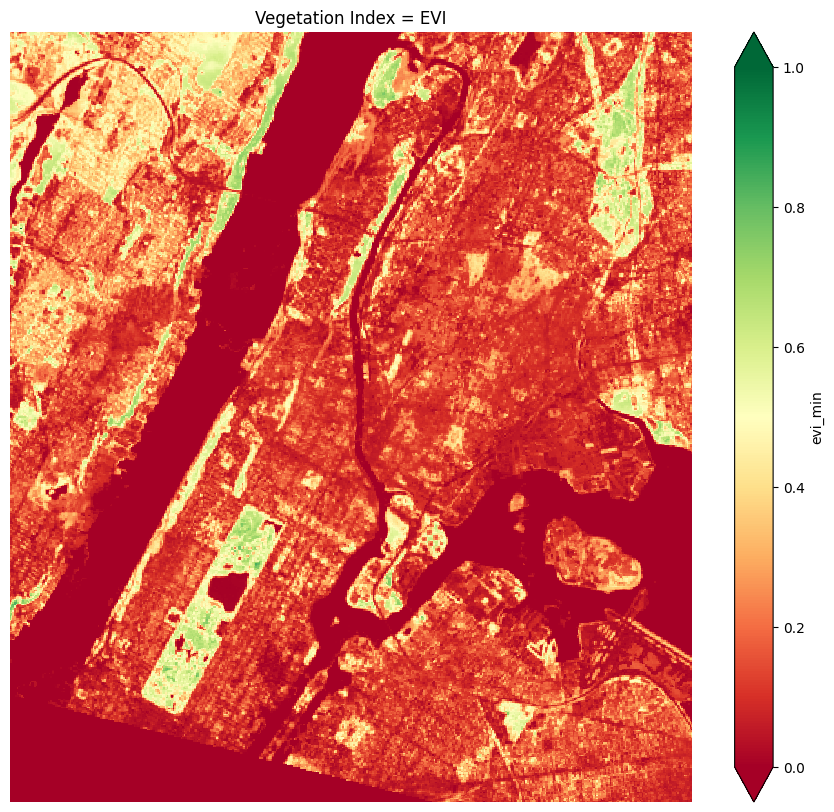

In [ ]:
fig, ax = plt.subplots(figsize=(11,10))
evi_min.plot.imshow(vmin=0.0, vmax=1.0, cmap="RdYlGn")
plt.title("Vegetation Index = EVI")
plt.axis('off')
plt.show()

In [ ]:
from pathlib import Path

def export_to_tif(item, output_name, lower_left, upper_right, crs="epsg:4326", count=None):
    # Creating Dir if not exists
    path = Path(output_name)
    path.resolve().parents[0].mkdir(parents=True, exist_ok=True)

    height = item.sizes["latitude"]
    width = item.sizes["longitude"]
    gt = rasterio.transform.from_bounds(
        lower_left[1],
        lower_left[0],
        upper_right[1],
        upper_right[0],
        width,
        height
    )
    item.rio.write_crs(crs, inplace=True)
    item.rio.write_transform(transform=gt, inplace=True)

    with rasterio.open(output_name, "w", driver="GTiff", width=width,
                       height=height, crs=crs, transform=gt, count=count,
                       compress="lzw", dtype="float64") as dst:
        if hasattr(item, "to_dataarray"):
            dst.write(item.to_dataarray())
            return

        if len(item.shape) == 2:
            dst.write(item.values.reshape(1, height, width))
            return

        else:
            dst.write(item)
            return

In [ ]:
from tqdm import tqdm
for data in tqdm(landsat_to_export):
    filename = f"Train/{data.name}.tiff"
    export_to_tif(data, filename, lower_left, upper_right, count=1)

100%|██████████| 102/102 [02:33<00:00,  1.50s/it]


# Sentinel 2 L2a Data

In [ ]:
stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = stac.search(
    bbox=bounds,
    datetime=time_window,
    collections=["sentinel-2-l2a"],
    query={"eo:cloud_cover": {"lt": 80}},
)

resolution = 10  # meters per pixel
scale = resolution / 111320.0 # degrees per pixel for crs=4326

items = list(search.items())
items[0]

<Item id=S2A_MSIL2A_20210731T153911_R011_T18TWL_20210801T071615>

In [ ]:
data = stac_load(
    items,
    bands=["B01", "B02", "B03", "B04",
           "B05", "B06", "B07", "B08",
           "B8A", "B11", "B12", "AOT",
           "SCL", "WVP"],
    crs="EPSG:4326", # Latitude-Longitude
    resolution=scale, # Degrees
    chunks={"x": 2048, "y": 2048},
    dtype="uint16",
    patch_url=planetary_computer.sign,
    bbox=bounds
)
print("Avaliable assets:")
print(pd.Series(list(items[0].assets.keys())))

Avaliable assets:
0                    AOT
1                    B01
2                    B02
3                    B03
4                    B04
5                    B05
6                    B06
7                    B07
8                    B08
9                    B09
10                   B11
11                   B12
12                   B8A
13                   SCL
14                   WVP
15                visual
16               preview
17         safe-manifest
18      granule-metadata
19      inspire-metadata
20      product-metadata
21    datastrip-metadata
22              tilejson
23      rendered_preview
dtype: object


In [ ]:
display(data)

<xarray.Dataset> Size: 949MB
Dimensions:      (latitude: 1448, longitude: 1671, time: 14)
Coordinates:
  * latitude     (latitude) float64 12kB 40.88 40.88 40.88 ... 40.75 40.75 40.75
  * longitude    (longitude) float64 13kB -74.01 -74.01 -74.01 ... -73.86 -73.86
    spatial_ref  int32 4B 4326
  * time         (time) datetime64[ns] 112B 2021-06-06T15:38:09.024000 ... 20...
Data variables: (12/14)
    B01          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B02          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B03          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B04          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B05          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B06          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    ...           ...
    B8A          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B11          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    B12          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    AOT          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    SCL          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>
    WVP          (time, latitude, longitude) uint16 68MB dask.array<chunksize=(1, 1448, 1671), meta=np.ndarray>

In [ ]:
median = data.median(dim="time")
mean = data.mean(dim="time")
max = data.max(dim="time")
min = data.min(dim="time")
std = data.std(dim="time")
var = data.var(dim="time")

In [ ]:
stats = ["median", "mean", "max", "min", "std", "var"]
sentinel_to_export = list()

for stat in stats:
    exec(f"ndbi_{stat} = ({stat}.B11-{stat}.B08) / ({stat}.B11+{stat}.B08)")
    exec(f"ndmi_{stat} = ({stat}.B08-{stat}.B11) / ({stat}.B08+{stat}.B11)")
    exec(f"ndwi_{stat} = ({stat}.B03-{stat}.B08) / ({stat}.B03+{stat}.B08)")
    exec(f"coast_aerosol_{stat} = {stat}.B01 # = Coastal Aerosol = 60m")
    exec(f"swir16_{stat} = {stat}.B11 # = SWIR (1.6 um) = 20m")
    exec(f"swir22_{stat} = {stat}.B12 # = SWIR (2.2 um) = 20m")
    exec(f"scl_{stat} = {stat}.SCL # = Scene Classification")
    exec(f"wvp_{stat} = {stat}.WVP / 1000 # Watervapor * scale factor")
    exec(f"mndwi_{stat} = ({stat}.B03-{stat}.B11) / ({stat}.B03+{stat}.B11)")
    exec(f'''
bands = [
    f"ndbi_{stat}",
    f"ndmi_{stat}",
    f"ndwi_{stat}",
    f"coast_aerosol_{stat}",
    f"swir16_{stat}",
    f"swir22_{stat}",
    f"scl_{stat}",
    f"wvp_{stat}",
    f"mndwi_{stat}",
]
    ''')

    for band in bands:
        str_eval = f"{band}.name = '{band}'"
        exec(str_eval)
        sentinel_to_export.append(eval(f"{band}"))

In [ ]:
sorted(list(map(lambda x: x.name, sentinel_to_export)))

['coast_aerosol_max',
 'coast_aerosol_mean',
 'coast_aerosol_median',
 'coast_aerosol_min',
 'coast_aerosol_std',
 'coast_aerosol_var',
 'mndwi_max',
 'mndwi_mean',
 'mndwi_median',
 'mndwi_min',
 'mndwi_std',
 'mndwi_var',
 'ndbi_max',
 'ndbi_mean',
 'ndbi_median',
 'ndbi_min',
 'ndbi_std',
 'ndbi_var',
 'ndmi_max',
 'ndmi_mean',
 'ndmi_median',
 'ndmi_min',
 'ndmi_std',
 'ndmi_var',
 'ndwi_max',
 'ndwi_mean',
 'ndwi_median',
 'ndwi_min',
 'ndwi_std',
 'ndwi_var',
 'scl_max',
 'scl_mean',
 'scl_median',
 'scl_min',
 'scl_std',
 'scl_var',
 'swir16_max',
 'swir16_mean',
 'swir16_median',
 'swir16_min',
 'swir16_std',
 'swir16_var',
 'swir22_max',
 'swir22_mean',
 'swir22_median',
 'swir22_min',
 'swir22_std',
 'swir22_var',
 'wvp_max',
 'wvp_mean',
 'wvp_median',
 'wvp_min',
 'wvp_std',
 'wvp_var']

In [ ]:
from tqdm import tqdm

for data in tqdm(sentinel_to_export):
    filename = f"Train/{data.name}.tiff"
    export_to_tif(data, filename, lower_left, upper_right, count=1)

 50%|█████     | 27/54 [02:21<01:43,  3.84s/it]/usr/local/lib/python3.11/dist-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
 52%|█████▏    | 28/54 [02:27<02:00,  4.62s/it]/usr/local/lib/python3.11/dist-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
 54%|█████▎    | 29/54 [02:33<02:03,  4.94s/it]/usr/local/lib/python3.11/dist-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
 65%|██████▍   | 35/54 [02:52<00:59,  3.12s/it]/usr/local/lib/python3.11/dist-packages/dask/core.py:133: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
100%|██████████| 54/54 [05:01<00:00,  5.59s/it]


# Building Features

In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from fiona.drvsupport import supported_drivers
from tqdm import tqdm
import pandas as pd


def calculate_stats_distance_to_N_polygons(row, polygons, N):
    """Calculate the average distance to the nearest N polygons for a given point (row) using spatial indexing."""
    point = row.geometry
    sindex = polygons.sindex

    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    sorted_distances = sorted(distances)[:N]
    return np.mean(sorted_distances), np.median(sorted_distances), np.max(sorted_distances), np.min(sorted_distances)

def calculate_building_density(row, polygons, buffer_radius):
    """Calculate building density (number of building footprints per unit area) within a buffer zone around the point."""
    point = row.geometry
    buffer_zone = point.buffer(buffer_radius)
    nearby_buildings = polygons[polygons.intersects(buffer_zone)]
    density = len(nearby_buildings) / buffer_zone.area
    return density

def calculate_building_area_density(row, polygons, buffer_radius):
    """Calculate building area density within a buffer zone around the point."""
    point = row.geometry
    buffer_zone = point.buffer(buffer_radius)
    nearby_buildings = polygons[polygons.intersects(buffer_zone)]
    total_area = nearby_buildings.geometry.area.sum()
    return total_area / buffer_zone.area

def calculate_nearest_building_size(row, polygons):
    """Calculate the area of the nearest building polygon to the point."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute the distance to the nearest polygon (there should be just one polygon)
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]
    return nearest_polygon.area

def calculate_neighboring_polygon_intersection(row, polygons):
    """Calculate the intersection of the nearest polygon with its neighboring polygons."""
    point = row.geometry
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()  # Adjust num_results as necessary
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]

    # Find neighboring polygons that intersect the nearest polygon
    neighbors = polygons[polygons.intersects(nearest_polygon)]
    intersection_area = nearest_polygon.intersection(unary_union(neighbors)).area
    return intersection_area

def calculate_point_relative_position_to_building_boundary(row, polygons):
    """Determine if the point is closer to the edge, center, or corners of the building polygon."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()   # Adjust num_results as needed
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]

    # Determine the relative position to the nearest polygon's boundary
    boundary_distance = point.distance(nearest_polygon.boundary)
    centroid_distance = point.distance(nearest_polygon.centroid)

    if boundary_distance < centroid_distance:
        return 1 # "1st (closer to edge)"
    elif boundary_distance > centroid_distance:
        return 2 # "2nd (closer to center)"
    else:
        return 3 # "3rd (equidistant)"

def calculate_nearest_polygon_angle(row, polygons):
    """Calculate the angle of the point relative to the orientation of the nearest polygon."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()   # Only 1 nearest match
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]

    # Calculate the angle relative to the centroid of the nearest polygon
    centroid = nearest_polygon.centroid
    angle = np.arctan2(centroid.y - point.y, centroid.x - point.x)
    return np.degrees(angle)

def calculate_variation_in_distance_to_multiple_polygons(row, polygons, N):
    """Calculate the standard deviation or range of distances to the N nearest polygons."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()   # Adjust num_results as necessary
    possible_matches_index[::-1].sort()   # Adjust num_results as necessary
    possible_matches = polygons.iloc[possible_matches_index[:N]]

    # Compute distances to the filtered set of polygons
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    sorted_distances = sorted(distances)[:N]
    return np.std(sorted_distances), np.ptp(sorted_distances)  # standard deviation and range

def calculate_nearest_polygon_shape_stats_complexity(row, polygons):
    """Calculate the average complexity of the nearest polygon's shape using the number of vertices or fractal dimension."""
    point = row.geometry
    # Create spatial index for polygons
    sindex = polygons.sindex
    possible_matches_index = sindex.nearest(point).squeeze()
    possible_matches_index[::-1].sort()  # Adjust num_results as necessary
    possible_matches = polygons.iloc[possible_matches_index[:10]]

    # Compute distances and find the nearest polygon
    distances = [point.distance(polygon) for polygon in possible_matches.geometry]
    nearest_polygon = possible_matches.iloc[np.argmin(distances)]
    vertices = np.array([np.array(geom.exterior.coords.xy[0]).shape[0] for geom in nearest_polygon.geoms])
    avg_vertices = vertices.mean()
    median_vertices = np.median(vertices)
    max_vertices = vertices.max()
    min_vertices = vertices.min()
    std_vertices = vertices.std()
    range_vertices = max_vertices - min_vertices
    return avg_vertices, median_vertices, max_vertices, min_vertices, std_vertices, range_vertices


In [ ]:
def get_point(row):
    return Point(row["Longitude"], row["Latitude"])

def create_building_features(
    df,
    min_distance,
    max_distance,
    step,
    buffer_radius=100,  # meter
    N=50, # N buildings
):
    print("Loading footprint...")
    epsg_distance = "32633"
    epsg_read = "4326"
    supported_drivers['LIBKML'] = 'rw'
    my_map = gpd.read_file('/content/Dataset/Building_Footprint.kml', driver='LIBKML')
    my_map.to_crs(epsg=epsg_distance, inplace=True)

    print("Creating points...")
    geometric_points = df.apply(get_point, axis=1).to_numpy().tolist()
    geo_locations = gpd.GeoDataFrame(
        df,
        crs=f'epsg:{epsg_read}',
        geometry = geometric_points
    )
    geo_locations.to_crs(epsg=epsg_distance, inplace=True)

    print("Adding 'is_building'...")
    is_building = list()
    for i in range(0, len(geo_locations)):
        point = geo_locations.geometry.loc[i]
        check = any(my_map.contains(point).values)
        is_building.append(check)
    geo_locations["is_a_building"] = list(map(int, is_building))

    print("Calculating nearest bulding distance...")
    assert geo_locations.crs == my_map.crs, "CRS must match!"
    geo_locations['nearest_building_distance'] = geo_locations.apply(
        lambda row: my_map.distance(row.geometry).min(), axis=1
    )

    print("Counting buildings near threshold...")
    threshold_distances = tqdm(list(range(min_distance, max_distance+step, step))) # meters
    # Nearest bulding count of x meter distance
    for distance in threshold_distances:
        geo_locations[f'{distance}m_nearby_building_count'] = geo_locations.apply(
            lambda row: my_map[my_map.geometry.intersects(row.geometry.buffer(distance))].shape[0], axis=1
        )

    print("Calculating 'stats_distance...")
    geo_locations['average_distance'], geo_locations['median_distance'], geo_locations['max_distance'], geo_locations['min_distance'] = (
        zip(*geo_locations.apply(calculate_stats_distance_to_N_polygons, axis=1, polygons=my_map.geometry, N=N))
    )

    print("Calculating 'building_density...")
    geo_locations['building_density'] = geo_locations.apply(calculate_building_density, axis=1, polygons=my_map, buffer_radius=buffer_radius)

    print("Calculating 'building_area_density...")
    geo_locations['building_area_density'] = geo_locations.apply(calculate_building_area_density, axis=1, polygons=my_map, buffer_radius=buffer_radius)

    print("Calculating 'nearest_building_size...")
    geo_locations['nearest_building_size'] = geo_locations.apply(calculate_nearest_building_size, axis=1, polygons=my_map.geometry)

    print("Calculating 'neighboring_intersection...")
    geo_locations['neighboring_intersection'] = geo_locations.apply(calculate_neighboring_polygon_intersection, axis=1, polygons=my_map.geometry)

    print("Calculating 'relative_position...")
    geo_locations['relative_position'] = geo_locations.apply(calculate_point_relative_position_to_building_boundary, axis=1, polygons=my_map.geometry)

    print("Calculating 'nearest_polygon_angle...")
    geo_locations['nearest_polygon_angle'] = geo_locations.apply(calculate_nearest_polygon_angle, axis=1, polygons=my_map.geometry)

    print("Calculating 'distance_variation...")
    geo_locations['distance_variation'], geo_locations['distance_range'] = zip(*geo_locations.apply(calculate_variation_in_distance_to_multiple_polygons, axis=1, polygons=my_map.geometry, N=N))

    print("Calculating 'stats_polygon_complexity...")
    geo_locations['avg_polygon_complexity'], geo_locations['median_polygon_complexity'], geo_locations['max_polygon_complexity'], geo_locations['min_polygon_complexity'], geo_locations['std_polygon_complexity'], geo_locations['range_polygon_complexity'] = (
        zip(*geo_locations.apply(calculate_nearest_polygon_shape_stats_complexity, axis=1, polygons=my_map.geometry))
    )
    print("Done!")
    return geo_locations

In [ ]:
min_distance = 10  # Untuk yang counting
max_distance = 20
step = 10
buffer_radius = 100  # meter
N = 50

date_format = "%d-%m-%Y %H:%M"
df = pd.read_csv(
    "Training_data_uhi_index.csv",
    date_format=date_format,
    parse_dates=["datetime"]
)
df_building_train = create_building_features(
    df,
    min_distance=min_distance,
    max_distance=max_distance,
    step=step,
    buffer_radius=buffer_radius,  # meter
    N=N, # N buildings
)
df_building_train

Loading footprint...
Creating points...
Adding 'is_building'...
Calculating nearest bulding distance...
Counting buildings near threshold...


100%|██████████| 2/2 [00:39<00:00, 19.95s/it]


Calculating 'average_distance...
Calculating 'building_density...
Calculating 'building_area_density...
Calculating 'nearest_building_size...
Calculating 'neighboring_intersection...
Calculating 'relative_position...
Calculating 'nearest_polygon_angle...
Calculating 'distance_variation...
Calculating 'stats_polygon_complexity...
Done!


,Longitude,Latitude,datetime,UHI Index,geometry,is_a_building,nearest_building_distance,10m_nearby_building_count,20m_nearby_building_count,average_distance,...,relative_position,nearest_polygon_angle,distance_variation,distance_range,avg_polygon_complexity,median_polygon_complexity,max_polygon_complexity,min_polygon_complexity,std_polygon_complexity,range_polygon_complexity
0,-73.909167,40.813107,2021-07-24 15:53:00,1.030289,POINT (-5804933.414 9857596.811),0,19.079136,0,1,3029.494982,...,1,-157.415935,3010.415846,6020.831692,29.0,29.0,29,29,0.0,0
1,-73.909187,40.813045,2021-07-24 15:53:00,1.030289,POINT (-5804943.928 9857599.08),0,19.233293,0,1,3034.387105,...,1,-153.907970,3015.153812,6030.307623,29.0,29.0,29,29,0.0,0
2,-73.909215,40.812978,2021-07-24 15:53:00,1.023798,POINT (-5804955.321 9857602.397),0,20.268009,0,0,3040.018287,...,1,-148.916535,3019.750278,6039.500556,29.0,29.0,29,29,0.0,0
3,-73.909242,40.812908,2021-07-24 15:53:00,1.023798,POINT (-5804967.271 9857605.484),0,20.968705,0,0,3045.783857,...,1,-142.868592,3024.815152,6049.630304,29.0,29.0,29,29,0.0,0
4,-73.909257,40.812845,2021-07-24 15:53:00,1.021634,POINT (-5804978.048 9857607.103),0,16.324876,0,1,3048.490175,...,1,-137.014238,3032.165299,6064.330598,29.0,29.0,29,29,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,2021-07-24 15:57:00,0.972470,POINT (-5808964.468 9863649.01),0,295.759464,0,0,5590.364545,...,1,68.494987,5294.605081,10589.210161,9.0,9.0,9,9,0.0,0
11225,-73.957063,40.790308,2021-07-24 15:57:00,0.972470,POINT (-5808968.75 9863650.609),0,295.705141,0,0,5592.616329,...,1,67.760171,5296.911189,10593.822377,9.0,9.0,9,9,0.0,0
11226,-73.957093,40.790270,2021-07-24 15:57:00,0.981124,POINT (-5808975.349 9863654.291),0,294.627364,0,0,5595.844866,...,1,66.551033,5301.217502,10602.435004,9.0,9.0,9,9,0.0,0
11227,-73.957112,40.790253,2021-07-24 15:59:00,0.981245,POINT (-5808978.238 9863656.573),0,293.594965,0,0,5597.118472,...,1,65.975980,5303.523507,10607.047014,9.0,9.0,9,9,0.0,0


In [ ]:
df_building_train.groupby("10m_nearby_building_count")["UHI Index"].agg(["mean", "max", "min", "median", "count"])

In [ ]:
sub_df = pd.read_csv(
    "Submission_template.csv",
)
df_building_submission = create_building_features(
    sub_df,
    min_distance=min_distance,
    max_distance=max_distance,
    step=step,
    buffer_radius=buffer_radius,  # meter
    N=N, # N buildings
)

Loading footprint...
Creating points...
Adding 'is_building'...
Calculating nearest bulding distance...
Counting buildings near threshold...


100%|██████████| 2/2 [00:03<00:00,  1.60s/it]


Calculating 'average_distance...
Calculating 'building_density...
Calculating 'building_area_density...
Calculating 'nearest_building_size...
Calculating 'neighboring_intersection...
Calculating 'relative_position...
Calculating 'nearest_polygon_angle...
Calculating 'distance_variation...
Calculating 'stats_polygon_complexity...
Done!


In [ ]:
df_building_train.iloc[:, 5:].to_csv("Train_Building_Features.csv", index=False)

In [ ]:
df_building_submission.iloc[:, 4:].to_csv("Submission_Building_Features.csv", index=False)

In [ ]:
!cp Train_Building_Features.csv "/content/drive/MyDrive/EY 2025"
!cp Submission_Building_Features.csv "/content/drive/MyDrive/EY 2025"

# TODO!

In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from fiona.drvsupport import supported_drivers
from tqdm import tqdm
import pandas as pd

epsg_distance = "32633"
epsg_read = "4326"
supported_drivers['LIBKML'] = 'rw'
my_map = gpd.read_file('/content/Dataset/Building_Footprint.kml', driver='LIBKML')
my_map.to_crs(epsg=epsg_distance, inplace=True)

In [ ]:
my_map

,Name,Description,geometry
0,,,"MULTIPOLYGON (((-5799031.11 9859035.865, -5799..."
1,,,"MULTIPOLYGON (((-5798799.952 9859418.3, -57987..."
2,,,"MULTIPOLYGON (((-5798712.737 9859234.378, -579..."
3,,,"MULTIPOLYGON (((-5798494.721 9859248.084, -579..."
4,,,"MULTIPOLYGON (((-5798332.238 9858196.404, -579..."
...,...,...,...
9431,,,"MULTIPOLYGON (((-5810829.324 9863032.542, -581..."
9432,,,"MULTIPOLYGON (((-5811343.474 9862627.669, -581..."
9433,,,"MULTIPOLYGON (((-5812594.475 9862910.409, -581..."
9434,,,"MULTIPOLYGON (((-5814249.507 9862889.433, -581..."


In [ ]:
##### POTENTIAL SHADE
import numpy as np
from pykml import parser
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union
from pyproj import Proj, transform
import pvlib
import datetime

# Step 1: Parse KML file to get building footprints
def parse_kml(kml_file):
    with open(kml_file) as f:
        doc = parser.parse(f)
        root = doc.getroot()

    buildings = []
    print(doc)
    print(root)
    print("------------------")
    print(root.Document.keys())
    print("------------------")
    print(root.Document.get("id").root_doc)
    print("------------------")
    print(root.Document.Folder.keys())
    print("------------------")
    print(root.Document.Folder.Placemark.keys())
    print("------------------")
    # for placemark in doc.Document.Folder.Placemark:
    #     print(placemark)
        # coords = placemark.Polygon.outerBoundaryIs.LinearRing.coordinates.text.strip()
        # coords = coords.split()
        # coords = [(float(coord.split(',')[0]), float(coord.split(',')[1])) for coord in coords]
        # buildings.append(Polygon(coords))
    return buildings

# Step 2: Convert geographic coordinates (lat, lon) to a projection (e.g., UTM)
def transform_coordinates(lat, lon):
    # Example for UTM (zone 33N, EPSG:32633)
    proj_wgs84 = Proj(init="epsg:4326")
    proj_utm = Proj(init="epsg:32633")
    x, y = transform(proj_wgs84, proj_utm, lon, lat)
    return x, y

# Step 3: Calculate sun position
def calculate_sun_position(latitude, longitude, date_time):
    # Use pvlib to calculate sun position
    times = pd.to_datetime([date_time])
    solar_position = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    azimuth = solar_position['azimuth'][0]
    altitude = solar_position['apparent_elevation'][0]
    return azimuth, altitude

# Step 4: Calculate shadow projection for a building based on sun position
def calculate_shadow(building, azimuth, altitude):
    # Simplified calculation for shadow based on sun position
    shadow_points = []
    for x, y in building.exterior.coords:
        # Calculate shadow points (this is a simplified version of ray casting)
        shadow_length = 10  # Placeholder for how long the shadow extends
        shadow_x = x + np.cos(np.radians(azimuth)) * shadow_length
        shadow_y = y + np.sin(np.radians(azimuth)) * shadow_length
        shadow_points.append((shadow_x, shadow_y))
    shadow_polygon = Polygon(shadow_points)
    return shadow_polygon

# Step 5: Check if point is in the shadow of any building
def is_point_in_shadow(point, buildings, azimuth, altitude):
    for building in buildings:
        shadow = calculate_shadow(building, azimuth, altitude)
        if shadow.contains(point):
            return True
    return False

# Example usage:
kml_file = '/content/Dataset/Building_Footprint.kml'
buildings = parse_kml(kml_file)
point = Point(500000, 4000000)  # Example point in UTM coordinates

# Calculate sun position for a given date and time
latitude, longitude = 52.5, 13.4  # Example latitude/longitude
date_time = datetime.datetime(2025, 1, 28, 12, 0)  # Noon on January 28, 2025
azimuth, altitude = calculate_sun_position(latitude, longitude, date_time)

# Check if point is in shadow
is_in_shadow = is_point_in_shadow(point, buildings, azimuth, altitude)
print("Is the point in shadow?", is_in_shadow)


------------------
['id']
------------------


AttributeError: 'str' object has no attribute 'root_doc'

In [ ]:
# # # SOLAR ENERGY!!!
import pvlib
import pandas as pd
from datetime import datetime

latitude = 52.5
longitude = 13.4
time_of_day = pd.to_datetime(datetime.utcnow())  # Current UTC time

# Calculate solar position
solar_position = pvlib.solarposition.get_solarposition(time_of_day, latitude, longitude)
zenith_angle = solar_position['zenith'].iloc[0]
azimuth_angle = solar_position['azimuth'].iloc[0]

print(f"Solar Zenith Angle: {zenith_angle}°")
print(f"Solar Azimuth Angle: {azimuth_angle}°")

####################
import numpy as np
from shapely.geometry import Polygon, Point

def calculate_shadow(building, azimuth, altitude):
    """Calculate shadow projection of a building based on sun position."""
    shadow_points = []
    shadow_length = 100  # Arbitrary length for simplicity; should depend on altitude

    for x, y in building.exterior.coords:
        # Calculate shadow points (simplified projection)
        shadow_x = x + np.cos(np.radians(azimuth)) * shadow_length
        shadow_y = y + np.sin(np.radians(azimuth)) * shadow_length
        shadow_points.append((shadow_x, shadow_y))

    shadow_polygon = Polygon(shadow_points)
    return shadow_polygon

# Example building footprint as a polygon (x, y coordinates)
building_coords = [(0, 0), (0, 10), (10, 10), (10, 0)]
building = Polygon(building_coords)

# Example solar azimuth and altitude (calculated earlier)
shadow = calculate_shadow(building, azimuth_angle, zenith_angle)

# Plot the shadow and building for visualization (optional)
import matplotlib.pyplot as plt

x, y = building.exterior.xy
plt.fill(x, y, alpha=0.5, label="Building Footprint")

shadow_x, shadow_y = shadow.exterior.xy
plt.fill(shadow_x, shadow_y, alpha=0.5, color='gray', label="Shadow")

plt.legend()
plt.show()

#######################
def point_in_shadow(point, shadow):
    """Check if point is inside the shadow."""
    return shadow.contains(point)

def calculate_energy_fraction(point, shadow):
    """Estimate solar energy fraction for a point based on proximity to shadow."""
    if point_in_shadow(point, shadow):
        return 0  # Full shadow, 0% energy
    else:
        # Simple model for energy based on proximity to shadow edge
        distance_to_edge = shadow.exterior.distance(point)
        max_distance = 50  # Arbitrary maximum distance for full sunlight
        fraction = max(0, 1 - (distance_to_edge / max_distance))
        return fraction

# Example point (latitude, longitude) converted to local coordinates (UTM, etc.)
point = Point(5, 5)  # Example point

# Calculate the energy fraction
energy_fraction = calculate_energy_fraction(point, shadow)
print(f"Energy Fraction: {energy_fraction * 100}%")

################################
def estimate_solar_energy(energy_fraction, solar_flux):
    """Estimate solar energy (W/m²) received at the point."""
    return energy_fraction * solar_flux

# Example solar flux (solar radiation in W/m²)
solar_flux = 1000  # Direct sunlight (100% of energy)

# Estimate the solar energy (W/m²)
solar_energy = estimate_solar_energy(energy_fraction, solar_flux)
print(f"Estimated Solar Energy (W/m²): {solar_energy}")


# PVLIB

In [ ]:
import pvlib
import pandas as pd
from datetime import datetime
import pytz

date_format = "%d-%m-%Y %H:%M"
df = pd.read_csv(
    '/content/Dataset/Training_data_uhi_index.csv',
    parse_dates=["datetime"],
    date_format=date_format
)
df.head()

,Longitude,Latitude,datetime,UHI Index
0,-73.909167,40.813107,2021-07-24 15:53:00,1.030289
1,-73.909187,40.813045,2021-07-24 15:53:00,1.030289
2,-73.909215,40.812978,2021-07-24 15:53:00,1.023798
3,-73.909242,40.812908,2021-07-24 15:53:00,1.023798
4,-73.909257,40.812845,2021-07-24 15:53:00,1.021634


In [ ]:
# Based on https://www.timeanddate.com/time/dst/2021.html, NY is in DST
df.datetime.agg(["min", "max"])


,datetime
min,2021-07-24 15:01:00
max,2021-07-24 15:59:00


In [ ]:
df["datetime_cnvrt"] = df.datetime.dt.tz_localize('America/New_York', ambiguous="infer")
df["datetime_cnvrt"] = df["datetime_cnvrt"].dt.tz_convert('UTC')
df.head()

,Longitude,Latitude,datetime,UHI Index,datetime_cnvrt
0,-73.909167,40.813107,2021-07-24 15:53:00,1.030289,2021-07-24 19:53:00+00:00
1,-73.909187,40.813045,2021-07-24 15:53:00,1.030289,2021-07-24 19:53:00+00:00
2,-73.909215,40.812978,2021-07-24 15:53:00,1.023798,2021-07-24 19:53:00+00:00
3,-73.909242,40.812908,2021-07-24 15:53:00,1.023798,2021-07-24 19:53:00+00:00
4,-73.909257,40.812845,2021-07-24 15:53:00,1.021634,2021-07-24 19:53:00+00:00


,count
datetime,
2021-07-24 15:53:00,248
2021-07-24 15:54:00,249
2021-07-24 15:55:00,317
2021-07-24 15:56:00,228
2021-07-24 15:57:00,262
2021-07-24 15:58:00,200
2021-07-24 15:59:00,259
2021-07-24 15:01:00,46
2021-07-24 15:02:00,66


In [ ]:
def get_solar_data(row):
    times, latitude, longitude = row.datetime_cnvrt, row.Latitude, row.Longitude
    solar_position = pvlib.solarposition.get_solarposition(times, latitude, longitude)
    loc = pvlib.location.Location(latitude, longitude, tz=times.tz)
    airmass = loc.get_airmass(
        times=solar_position.index,
        solar_position=solar_position[['apparent_zenith', 'zenith']]
    )
    clearsky = loc.get_clearsky(solar_position.index, solar_position=solar_position[["apparent_zenith", "zenith", "apparent_elevation"]])

    # Concatenate
    df_solar = pd.concat(
        [solar_position.reset_index(drop=True), airmass.reset_index(drop=True), clearsky.reset_index(drop=True)],
        axis=1
    )
    return df_solar
solar_data = pd.concat(df.apply(get_solar_data, axis=1).to_numpy().tolist()).reset_index(drop=True)

In [ ]:
assert solar_data.shape[0] == df.shape[0]

In [ ]:
solar_data

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time,airmass_relative,airmass_absolute,ghi,dni,dhi
0,41.929567,41.944683,48.070433,48.055317,252.833698,-6.530841,1.342817,1.338683,697.467538,771.425653,123.552454
1,41.929535,41.944650,48.070465,48.055350,252.833745,-6.530841,1.342816,1.338682,697.467968,771.425791,123.552487
2,41.929495,41.944610,48.070505,48.055390,252.833791,-6.530841,1.342816,1.338681,697.468496,771.425960,123.552528
3,41.929455,41.944570,48.070545,48.055430,252.833841,-6.530841,1.342815,1.338681,697.469022,771.426129,123.552569
4,41.929425,41.944541,48.070575,48.055459,252.833895,-6.530841,1.342814,1.338680,697.469410,771.426253,123.552599
...,...,...,...,...,...,...,...,...,...,...,...
11224,42.613266,42.628747,47.386734,47.371253,253.707275,-6.530869,1.357419,1.353240,688.908875,769.779611,122.396999
11225,42.613249,42.628730,47.386751,47.371270,253.707289,-6.530869,1.357419,1.353240,688.909098,769.779683,122.397016
11226,42.613216,42.628698,47.386784,47.371302,253.707302,-6.530869,1.357418,1.353239,688.909532,769.779824,122.397050
11227,42.976954,42.992633,47.023046,47.007367,254.146755,-6.530882,1.365396,1.361193,684.044402,768.188402,122.016285


In [ ]:
# Check significance
X = solar_data
y = df["UHI Index"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score
et = ExtraTreesRegressor(250, random_state=0, n_jobs=-1)
et.fit(X_train, y_train)
r2_score(y_test, et.predict(X_test))

0.9735729178465475

In [ ]:
importance = pd.DataFrame({"Features": X_train.columns, "Importance": et.feature_importances_}).sort_values("Importance", ascending=False).reset_index(drop=True)
importance

,Features,Importance
0,azimuth,0.138119
1,dhi,0.125610
2,dni,0.109967
3,elevation,0.087275
4,apparent_elevation,0.086771
5,airmass_relative,0.086112
6,apparent_zenith,0.085064
7,airmass_absolute,0.085044
8,ghi,0.084727
9,zenith,0.084650


Since the submission data has no datetime, I am assigning them by random choice

In [ ]:
datetime_train = df.datetime_cnvrt.value_counts(sort=False).sort_index()
datetime_train.head()

,count
datetime_cnvrt,
2021-07-24 19:01:00+00:00,46
2021-07-24 19:02:00+00:00,66
2021-07-24 19:03:00+00:00,37
2021-07-24 19:04:00+00:00,123
2021-07-24 19:05:00+00:00,41


<Axes: xlabel='datetime_cnvrt'>

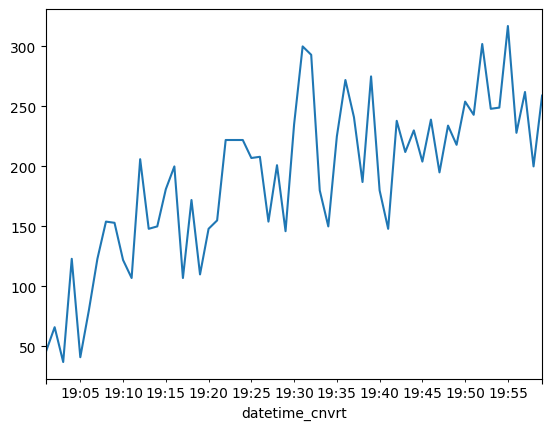

In [ ]:
datetime_train.plot()

<BarContainer object of 59 artists>

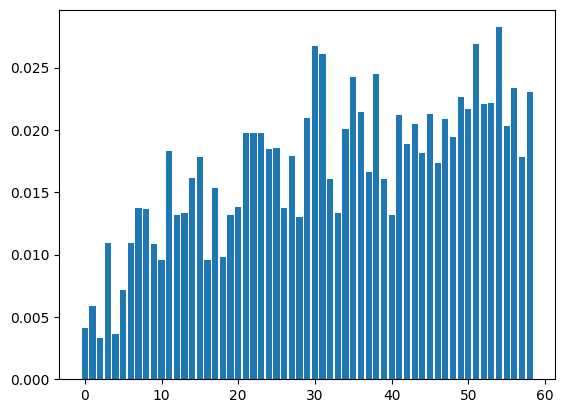

In [ ]:
# getting probabilities by using softmax
import scipy as sp
import matplotlib.pyplot as plt
# probabilities = sp.special.softmax(datetime_train)
# # plt.semilogy(range(len(probabilities)), probabilities)
probabilities = datetime_train / datetime_train.sum()
plt.bar(range(len(probabilities)), probabilities)

In [ ]:
# Submission has no datetime, so I am using mean of datetime in base data
mean_time = df.datetime_cnvrt.mean()
sub_df = pd.read_csv(
    '/content/Dataset/Submission_template.csv',
)
sub_df

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,NaN
1,-73.971928,40.788875,NaN
2,-73.967080,40.789080,NaN
3,-73.972550,40.789082,NaN
4,-73.969697,40.787953,NaN
...,...,...,...
1035,-73.919388,40.813803,NaN
1036,-73.931033,40.833178,NaN
1037,-73.934647,40.854542,NaN
1038,-73.917223,40.815413,NaN


In [ ]:
import numpy as np
np.random.seed(0)
datetime_cnvrt = np.random.choice(datetime_train.index, p=probabilities, size=sub_df.shape[0])
sub_df["datetime_cnvrt"] = datetime_cnvrt
sub_df

,Longitude,Latitude,UHI Index,datetime_cnvrt
0,-73.971665,40.788763,NaN,2021-07-24 19:38:00+00:00
1,-73.971928,40.788875,NaN,2021-07-24 19:47:00+00:00
2,-73.967080,40.789080,NaN,2021-07-24 19:41:00+00:00
3,-73.972550,40.789082,NaN,2021-07-24 19:38:00+00:00
4,-73.969697,40.787953,NaN,2021-07-24 19:32:00+00:00
...,...,...,...,...
1035,-73.919388,40.813803,NaN,2021-07-24 19:28:00+00:00
1036,-73.931033,40.833178,NaN,2021-07-24 19:23:00+00:00
1037,-73.934647,40.854542,NaN,2021-07-24 19:23:00+00:00
1038,-73.917223,40.815413,NaN,2021-07-24 19:14:00+00:00


In [ ]:
sub_df.datetime_cnvrt.value_counts()

,count
datetime_cnvrt,
2021-07-24 19:31:00+00:00,33
2021-07-24 19:32:00+00:00,31
2021-07-24 19:54:00+00:00,30
2021-07-24 19:57:00+00:00,29
2021-07-24 19:36:00+00:00,28
2021-07-24 19:22:00+00:00,27
2021-07-24 19:12:00+00:00,27
2021-07-24 19:58:00+00:00,27
2021-07-24 19:55:00+00:00,26


In [ ]:
solar_data_sub = pd.concat(sub_df.apply(get_solar_data, axis=1).to_numpy().tolist()).reset_index(drop=True)
solar_data_sub.head()

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time,airmass_relative,airmass_absolute,ghi,dni,dhi
0,39.191902,39.205626,50.808098,50.794374,249.277137,-6.530739,1.289137,1.285168,733.052756,783.535841,125.785985
1,40.796207,40.810733,49.203793,49.189267,251.427631,-6.530800,1.319696,1.315633,712.722580,777.349124,124.239515
2,39.727688,39.741676,50.272312,50.258324,250.010521,-6.530759,1.299071,1.295072,726.336908,781.519168,125.277723
3,39.191388,39.205112,50.808612,50.794888,249.275903,-6.530739,1.289127,1.285158,733.059161,783.537751,125.786469
4,38.135996,38.149212,51.864004,51.850788,247.781870,-6.530697,1.270315,1.266404,746.068147,787.370654,126.763952


In [ ]:
X_sub = solar_data_sub
sub_df["UHI Index"] = et.predict(X_sub)
sub_df.iloc[:, :-1].to_csv("SolarDataTestExtrapolateRandomChoice.csv", index=False)

# Zip final data

In [ ]:
!zip -r TrainTIFF.zip Train/ -9

  adding: Train/ (stored 0%)
  adding: Train/ndmi_max.tiff (deflated 4%)
  adding: Train/mndwi_median.tiff (deflated 4%)
  adding: Train/ndbi_median.tiff (deflated 4%)
  adding: Train/blue_min.tiff (deflated 13%)
  adding: Train/cdist_var.tiff (deflated 16%)
  adding: Train/lwir_std.tiff (deflated 16%)
  adding: Train/ndbi_std.tiff (deflated 4%)
  adding: Train/ndmi_median.tiff (deflated 4%)
  adding: Train/cdist_min.tiff (deflated 99%)
  adding: Train/ndvi_var.tiff (deflated 17%)
  adding: Train/red_std.tiff (deflated 15%)
  adding: Train/coast_aerosol_median.tiff (deflated 15%)
  adding: Train/swir22_std.tiff (deflated 9%)
  adding: Train/coast_aerosol_max.tiff (deflated 16%)
  adding: Train/ndwi_mean.tiff (deflated 4%)
  adding: Train/coast_aerosol_mean.tiff (deflated 14%)
  adding: Train/blue_median.tiff (deflated 12%)
  adding: Train/evi_max.tiff (deflated 16%)
  adding: Train/swir16_std.tiff (deflated 9%)
  adding: Train/drad_var.tiff (deflated 29%)
  adding: Train/qa_max.tiff (d

In [ ]:
!cp TrainTIFF.zip "/content/drive/MyDrive/EY 2025"